# Getting started with cost minimization in `optimex`

This notebook demonstrates a compact end-to-end workflow for cost-minimizing time-explicit Life Cycle Optimization (LCO) in `optimex`. One synthetic product can be supplied by two alternative foreground processes. Both require an installation-related background purchase and a route-specific operating input. Time-dependent market prices are assigned to these directly purchased background products.

Using the same product system, the notebook determines:

1. the cost minimum without an environmental constraint,
2. the climate-impact minimum as a reference, and
3. the cost minimum subject to a cumulative climate budget.

Together, these scenarios show how prices, discounting, and a cumulative climate budget affect installation and operation decisions. All quantities, prices, lifetimes, and environmental impacts are synthetic assumptions for demonstration purposes. The example demonstrates the software workflow; it is not a technology forecast or an empirical case study.

## 1. Setup

Use a notebook kernel with this repository's `optimex`, Brightway,
`bw_temporalis`, Matplotlib, and the HiGHS solver (`highspy`) installed; see the
[installation guide](../docs/content/installation.md).
No ecoinvent data are needed.

The following cells write synthetic data to the dedicated Brightway project
`optimex_basic_example_econ_simple`. Rerunning replaces only this example's named
databases and method; do not store other work in that project.

In [1]:
from datetime import datetime
import sys
import warnings

warnings.filterwarnings("ignore", message="No fast sparse solver found")
warnings.filterwarnings(
    "ignore", message=r"urllib3 .* doesn't match a supported version!"
)

import bw2data as bd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from bw_temporalis import TemporalDistribution
from IPython.display import display
from loguru import logger

from optimex import converter, lca_processor, optimizer, postprocessing
from optimex.economics import set_market_prices

# Keep the tutorial output focused on the inputs and results below.
logger.remove()
logger.add(sys.stderr, level="WARNING")

bd.projects.set_current("optimex_basic_example_econ_simple")

## 2. Product system and assumptions



Rectangles are **processes**; the oval is a **product**. Dashed arrows denote
fixed background supplies, not additional technology choices. Both processes
also emit CO2 directly. Construction and operating supplies carry upstream CO2.

The conventional process needs less construction input; the advanced process
needs twice as much, but emits less during operation. Their route-specific
operating inputs are named `conventional_input` and `advanced_input`.

- Demand: 10 product units each year, 2025-2034; no initial capacity.
- One installed process unit can supply 1 product unit per year for five years,
  including its installation year. Capacity is continuous and can be idle.
- Costs: illustrative **real EUR with a 2025 price basis**, discounted at 3% to
  2025. No inflation, revenues, CO2 price, end-of-life costs, or residual value.
- Climate: kg CO2-eq, including foreground and background emissions, with a
  static factor of 1 kg CO2-eq/kg CO2. Impacts are not discounted.

Only the price of the advanced operating input changes. Technical coefficients
and background emission factors stay constant, isolating the price effect. The
falling price is an external assumption, **not endogenous technological learning**.

In [2]:
years = np.arange(2025, 2035)
lifetime = 5
annual_demand = 10.0
discount_rate = 0.03
background_databases = {2025: "background_2025", 2034: "background_2034"}

background_parameters = pd.DataFrame([
    {"input": "construction", "role": "installation, both routes",
     "kg CO2/unit": 1.0,
     "price in 2025 [EUR_2025/unit]": 4.0,
     "price in 2034 [EUR_2025/unit]": 4.0},
    {"input": "conventional_input", "role": "operation, conventional",
     "kg CO2/unit": 2.0,
     "price in 2025 [EUR_2025/unit]": 5.0,
     "price in 2034 [EUR_2025/unit]": 5.0},
    {"input": "advanced_input", "role": "operation, advanced",
     "kg CO2/unit": 1.0,
     "price in 2025 [EUR_2025/unit]": 6.0,
     "price in 2034 [EUR_2025/unit]": 3.0},
]).set_index("input")
background_parameters

,role,kg CO2/unit,price in 2025 [EUR_2025/unit],price in 2034 [EUR_2025/unit]
input,,,,
construction,"installation, both routes",1.0,4.0,4.0
conventional_input,"operation, conventional",2.0,5.0,5.0
advanced_input,"operation, advanced",1.0,6.0,3.0


## 3. Brightway data and market prices

The two background snapshots have identical inventories but different prices.
`optimex` interpolates the snapshot prices for the intervening calendar years.
All prices are expressed in real EUR with a 2025 price basis. Prices are attached
to **directly purchased background nodes**, not to foreground processes or
recursively to upstream exchanges. Foreground exchange amounts determine the
quantities purchased.

In [3]:
%%capture
biosphere = bd.Database("biosphere3")
biosphere.write({
    ("biosphere3", "CO2"): {
        "name": "carbon dioxide", "unit": "kg",
        "type": bd.labels.biosphere_node_default,
    },
})
method = ("illustrative", "climate_change")
bd.Method(method).register(unit="kg CO2-eq")
bd.Method(method).write([(("biosphere3", "CO2"), 1.0)])

for year, db_name in background_databases.items():
    data = {}
    for name, row in background_parameters.iterrows():
        data[(db_name, name)] = {
            "name": name, "reference product": name,
            "location": "GLO", "unit": "unit",
            "type": bd.labels.chimaera_node_default,
            "exchanges": [
                {"input": (db_name, name), "amount": 1.0,
                 "type": bd.labels.production_edge_default},
                {"input": ("biosphere3", "CO2"), "amount": row["kg CO2/unit"],
                 "type": bd.labels.biosphere_edge_default},
            ],
        }
    db = bd.Database(db_name)
    db.write(data)
    db.metadata["representative_time"] = datetime(year, 1, 1).isoformat()
    db.register()

In [4]:
price_data = pd.DataFrame([
    {"name": name, "location": "GLO", "year": year,
     "price": row[f"price in {year} [EUR_2025/unit]"]}
    for name, row in background_parameters.iterrows()
    for year in background_databases
])
set_market_prices(price_data, background_databases)

## 4. Installation, operation, and demand

Relative `TemporalDistribution` dates describe years since installation.
`operation=False` links construction to installed units, even if they are idle.
`operation=True` links production, operating purchases, and direct emissions to
the units actually running in each year.

The operation distribution has five weights of 1/5. **Exchange amounts below
are full-lifetime quantities**: production of 5 units becomes 1 unit/year;
5 units of operating input become 1 unit/year. Conventional direct CO2 is
4 kg/year, advanced direct CO2 is 1 kg/year, per running process unit.

In [5]:
installation_td = TemporalDistribution(
    date=np.array([0], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)
operation_td = TemporalDistribution(
    date=np.arange(lifetime).astype("timedelta64[Y]"),
    amount=np.full(lifetime, 1.0 / lifetime),
)

foreground_data = {
    ("foreground", "product"): {
        "name": "Product", "unit": "unit",
        "type": bd.labels.product_node_default,
    },
}

In [6]:
foreground_data[("foreground", "conventional")] = {
    "name": "Conventional", "location": "GLO",
    "type": bd.labels.process_node_default,
    "operation_time_limits": (0, lifetime - 1),
    "exchanges": [
        {"input": ("foreground", "product"), "amount": float(lifetime),
         "type": bd.labels.production_edge_default,
         "temporal_distribution": operation_td, "operation": True},
        {"input": ("background_2025", "construction"), "amount": 1.0,
         "type": bd.labels.consumption_edge_default,
         "temporal_distribution": installation_td, "operation": False},
        {"input": ("background_2025", "conventional_input"), "amount": float(lifetime),
         "type": bd.labels.consumption_edge_default,
         "temporal_distribution": operation_td, "operation": True},
        {"input": ("biosphere3", "CO2"), "amount": 4.0 * lifetime,
         "type": bd.labels.biosphere_edge_default,
         "temporal_distribution": operation_td, "operation": True},
    ],
}

In [7]:
%%capture
foreground_data[("foreground", "advanced")] = {
    "name": "Advanced", "location": "GLO",
    "type": bd.labels.process_node_default,
    "operation_time_limits": (0, lifetime - 1),
    "exchanges": [
        {"input": ("foreground", "product"), "amount": float(lifetime),
         "type": bd.labels.production_edge_default,
         "temporal_distribution": operation_td, "operation": True},
        {"input": ("background_2025", "construction"), "amount": 2.0,
         "type": bd.labels.consumption_edge_default,
         "temporal_distribution": installation_td, "operation": False},
        {"input": ("background_2025", "advanced_input"), "amount": float(lifetime),
         "type": bd.labels.consumption_edge_default,
         "temporal_distribution": operation_td, "operation": True},
        {"input": ("biosphere3", "CO2"), "amount": 1.0 * lifetime,
         "type": bd.labels.biosphere_edge_default,
         "temporal_distribution": operation_td, "operation": True},
    ],
}
bd.Database("foreground").write(foreground_data)

In [8]:
demand_td = TemporalDistribution(
    date=np.array([f"{year}-01-01" for year in years], dtype="datetime64[s]"),
    amount=np.full(len(years), annual_demand),
)
functional_demand = {bd.get_node(database="foreground", code="product"): demand_td}

## 5. Prepare optimization inputs

`LCADataProcessor` reads the Brightway system and constructs the time-explicit
inventory and impact data. `ModelInputManager` transfers these data, including
the interpolated annual prices, and adds the discount rate and its reference
year. Demand dates define the modeled years, 2025-2034. This finite-horizon
example does not account for operation after 2034 or remaining asset value, so
late investments must be interpreted with that boundary in mind.

In [9]:
%%capture
config = lca_processor.LCAConfig(
    demand=functional_demand,
    temporal={
        "start_date": datetime(2025, 1, 1),
        "temporal_resolution": "year",
        "database_dates": {
            name: datetime(year, 1, 1) for year, name in background_databases.items()
        },
    },
    characterization_methods=[{
        "category_name": "climate_change", "brightway_method": method,
    }],
)
processor = lca_processor.LCADataProcessor(config)
manager = converter.ModelInputManager()
manager.parse_from_lca_processor(processor)
inputs = manager.override(
    discount_rate=discount_rate, discount_reference_year=int(years[0]),
)

In [10]:
# Inspect how snapshot prices were interpolated and assigned to each cost component.
processed_prices = pd.DataFrame({
    "installation-related: construction": [
        inputs.intermediate_costs_cap["construction", int(year)] for year in years
    ],
    "operation-related: conventional input": [
        inputs.intermediate_costs_op["conventional_input", int(year)] for year in years
    ],
    "operation-related: advanced input": [
        inputs.intermediate_costs_op["advanced_input", int(year)] for year in years
    ],
}, index=years)
processed_prices.index.name = "Year"
processed_prices.columns.name = "Price [EUR_2025/unit]"
processed_prices

Price [EUR_2025/unit],installation-related: construction,operation-related: conventional input,operation-related: advanced input
Year,,,
2025,4.0,5.0,6.000000
2026,4.0,5.0,5.666667
2027,4.0,5.0,5.333333
2028,4.0,5.0,5.000000
2029,4.0,5.0,4.666667
2030,4.0,5.0,4.333333
2031,4.0,5.0,4.000000
2032,4.0,5.0,3.666667
2033,4.0,5.0,3.333333


## 6. Cost minimum and climate reference

The first model minimizes discounted background-purchase costs. A second model
uses the original environmental objective to establish the minimum climate
impact attainable with the same demand, inventories, and technologies. The
`create_model` requires an `objective_category` argument for both objective
types. For the cost model, `objective="cost"` selects total discounted cost
regardless of the supplied category.

In [11]:
%%capture
cost_model = optimizer.create_model(
    inputs, name="cost_minimum", objective="cost", objective_category="climate_change",
)
cost_model, minimum_cost, _ = optimizer.solve_model(
    cost_model, solver_name="highs", tee=False,
)

In [12]:
%%capture
climate_model = optimizer.create_model(
    inputs, name="climate_reference",
    objective="environmental", objective_category="climate_change",
)
climate_model, minimum_climate, _ = optimizer.solve_model(
    climate_model, solver_name="highs", tee=False,
)

## 7. Cost minimum with a cumulative climate budget

The illustrative budget is **330 kg CO2-eq over all ten years**, not an annual
limit or a carbon price. It lies between the climate impacts of the two reference
solutions and therefore creates a trade-off between the two objectives. The
value is a synthetic assumption, not a policy target derived from external
evidence.

Only one input changes: `cumulative_category_impact_limits`.

In [13]:
%%capture
def climate_total(model):
    impacts = postprocessing.PostProcessor(model).get_impacts()
    return impacts["climate_change"].to_numpy().sum()


climate_budget = 330.0
assert minimum_climate < climate_budget < climate_total(cost_model)
constrained_inputs = manager.override(
    cumulative_category_impact_limits={"climate_change": climate_budget},
)
constrained_model = optimizer.create_model(
    constrained_inputs, name="cost_with_climate_budget",
    objective="cost", objective_category="climate_change",
)
constrained_model, constrained_cost, _ = optimizer.solve_model(
    constrained_model, solver_name="highs", tee=False,
)

## 8. Results

The table compares total discounted cost and cumulative climate impact. The
installation-related and operation-related cost components are both discounted
and sum to the reported total. They follow the corresponding background
purchases and should not be interpreted as complete CAPEX and OPEX accounts;
for example, fixed operating costs are omitted.

In [14]:
models = {
    "Cost minimum": cost_model,
    "Climate reference": climate_model,
    "Cost + climate budget": constrained_model,
}
rows = []
for scenario, model in models.items():
    rows.append({
        "Scenario": scenario,
        "Total cost [EUR_2025 PV]": pyo.value(model.total_cost),
        "Climate [kg CO2-eq]": climate_total(model),
        "Installation-related cost [EUR_2025 PV]": sum(
            pyo.value(model.discount_factor[t] * model.cost_cap[t])
            for t in model.SYSTEM_TIME
        ),
        "Operation-related cost [EUR_2025 PV]": sum(
            pyo.value(model.discount_factor[t] * model.cost_op[t])
            for t in model.SYSTEM_TIME
        ),
    })
comparison = pd.DataFrame(rows).set_index("Scenario")
comparison.round(2)

,Total cost [EUR_2025 PV],Climate [kg CO2-eq],Installation-related cost [EUR_2025 PV],Operation-related cost [EUR_2025 PV]
Scenario,,,,
Cost minimum,494.86,430.0,109.01,385.85
Climate reference,551.52,240.0,149.01,402.51
Cost + climate budget,524.68,330.0,130.06,394.62


### Installation and production

Use the existing `PostProcessor` to extract results. The table shows **newly
installed process units**, not annual production. The plots show product
supplied in each year; since output is 1 unit per running process unit and year,
they also reveal which technology operates. A mix is allowed; these are not
integer, all-or-nothing plant choices.

In [15]:
postprocessors = {
    name: postprocessing.PostProcessor(model) for name, model in models.items()
}
routes = ["conventional", "advanced"]
production = {
    name: pp.get_production().xs("product", axis=1, level="Product")[routes]
    for name, pp in postprocessors.items()
}
installations = pd.concat({
    name: pp.get_installation()[routes] for name, pp in postprocessors.items()
}, names=["Scenario", "Installation year"])
installations.loc[installations.abs().sum(axis=1) > 1e-7].round(2)

Process                                  conventional  advanced
Scenario              Installation year                        
Cost minimum          2025                      10.00      0.00
                      2030                       0.00     10.00
Climate reference     2025                       0.00     10.00
                      2030                       0.00     10.00
Cost + climate budget 2025                       4.74      5.26
                      2030                       0.00     10.00

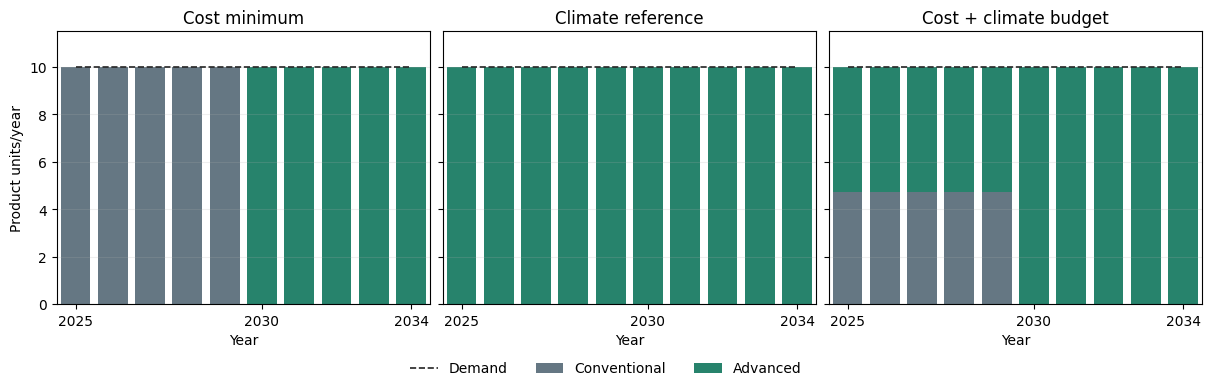

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True, layout="constrained")
for ax, (name, data) in zip(axes, production.items()):
    ax.bar(data.index, data["conventional"], color="#657783", label="Conventional")
    ax.bar(data.index, data["advanced"], bottom=data["conventional"],
           color="#27836c", label="Advanced")
    ax.plot(years, demand_td.amount, color="#242424", linestyle="--",
            linewidth=1.2, label="Demand")
    ax.set(title=name, xlabel="Year", xlim=(years[0] - 0.5, years[-1] + 0.5),
           ylim=(0, annual_demand * 1.15), xticks=[2025, 2030, 2034])
    ax.grid(axis="y", alpha=0.2)
axes[0].set_ylabel("Product units/year")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)
plt.show()

### Sanity checks and interpretation

The following checks confirm the annual-unit convention, price assignment,
demand fulfillment, cost identity, and cumulative climate budget for this
example. They do not constitute a test of every `optimex` feature. A
climate-minimizing solution is not necessarily the cheapest among multiple
solutions with the same minimum climate impact.

In [17]:
for route in ("conventional", "advanced"):
    assert all(
        np.isclose(inputs.foreground_production[route, "product", tau], 1.0)
        for tau in range(lifetime)
    )
assert {flow for flow, year in inputs.intermediate_costs_cap} == {"construction"}
assert {flow for flow, year in inputs.intermediate_costs_op} == {
    "conventional_input", "advanced_input",
}
np.testing.assert_allclose(
    [inputs.intermediate_costs_op["advanced_input", int(year)] for year in years],
    np.linspace(6.0, 3.0, len(years)),
)
for data in production.values():
    np.testing.assert_allclose(data.sum(axis=1), demand_td.amount, atol=1e-6)
np.testing.assert_allclose(
    comparison["Total cost [EUR_2025 PV]"],
    comparison["Installation-related cost [EUR_2025 PV]"]
    + comparison["Operation-related cost [EUR_2025 PV]"],
    atol=1e-6,
)
assert minimum_cost <= constrained_cost + 1e-6
assert minimum_climate - 1e-6 <= climate_total(constrained_model) <= climate_budget + 1e-6
assert constrained_cost <= pyo.value(climate_model.total_cost) + 1e-6

print(f"Cumulative climate impact: {climate_total(constrained_model):.2f} / "
      f"{climate_budget:.2f} kg CO2-eq")
print(f"Additional discounted cost versus cost minimum: "
      f"{constrained_cost - minimum_cost:.2f} EUR_2025")

Cumulative climate impact: 330.00 / 330.00 kg CO2-eq

Additional discounted cost versus cost minimum: 29.82 EUR_2025

The cost minimum initially uses the conventional process and switches to the
advanced process when capacity is replaced in 2030. Although the two operating
input prices are equal in 2028, the installation-related cost difference and
the five-year lifetimes affect the investment decision. The climate reference
uses the lower-emission advanced process, while the cumulative climate budget
brings part of this capacity forward relative to the unconstrained cost minimum.

These results illustrate the interaction of installation timing, operation,
prices, discounting, and a cumulative climate budget. The numerical transition
year and technology shares follow only from the synthetic inputs; they are not
general findings about either technology.

## 9. Further reading

The essential chain is **Brightway exchanges + background prices -> processed
inputs -> objective and optional constraint -> results**.

- [Economic optimization](../docs/content/economic_optimization.md): pricing,
  discounting, and cost interpretation.
- [Foreground modeling](../docs/content/foreground_modeling.md) and
  [constraints](../docs/content/constraints.md): lifecycle timing, existing
  capacity, technology changes, and deployment limits.
- [Postprocessing](../docs/content/postprocessing_guide.md): further result views.
- [Basic example](basic_example.ipynb) and [methanol and iron](methanol_and_iron.ipynb):
  multi-product and connected foreground systems.

Those extensions are intentionally outside this introductory example.